# Customer Segmentation & Cohort Retention Analysis
**Author:** Jayakumar P  
**Technologies:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-Learn (K-Means)  
**Dataset:** Online Retail (UCI Machine Learning Repository)  

---

## 1. Executive Summary & Domain Background
In modern e-commerce and retail analytics, sustainable business growth relies on understanding **Customer Lifetime Value (LTV)**, **Customer Retention Dynamics**, and **Behavioral Segmentation**. Traditional aggregate metrics (such as site-wide conversion rates or gross revenue) often mask underlying customer churn and shifting buyer demographics.

This project delivers an end-to-end analytical framework covering:
1. **Time-Based Cohort Analysis:** Tracking user retention rates over months since acquisition to diagnose churn velocity and retention curves.
2. **RFM Segmentation (Recency, Frequency, Monetary):** Value-based customer scoring to classify customers into actionable behavioral tiers (*Champions*, *Loyal Customers*, *At Risk*, etc.).
3. **Unsupervised Machine Learning (K-Means Clustering):** Algorithmic discovery of organic customer personas using de-skewed, standardized behavioral telemetry.
4. **Actionable Business Strategy:** Targeted marketing playbooks and churn intervention frameworks.

---

## 2. Cohort Analysis Theory

> **Definition:** A **Cohort** is a group of subjects who share a common defining characteristic or experience within a specific time period.

### Types of Cohorts:
- **Time Cohorts:** Customers who signed up or made their first purchase within a particular timeframe (monthly, quarterly, or daily). Tracking these cohorts isolates the impact of product releases, seasonality, and onboarding effectiveness.
- **Behavior Cohorts:** Customers grouped by their historical actions or subscription tiers (e.g., users who subscribed to premium vs. standard plans).
- **Size Cohorts:** Categorization based on initial purchase scale, monetary volume, or basket composition.

In this notebook, we implement **Monthly Acquisition Time Cohorts** to monitor retention decay and customer longevity across 13 months.

In [1]:
# Import Data Processing & Numerical Libraries
import numpy as np
import pandas as pd
import datetime as dt

# Import Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import Machine Learning Libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Set aesthetic plot configurations
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
%matplotlib inline

print('All libraries successfully imported!')

All libraries successfully imported!


## 3. Data Ingestion & Preprocessing

The **Online Retail** dataset contains 541,909 transactional records from a UK-based online retail enterprise operating between 01/12/2010 and 09/12/2011.

### Preprocessing Checklist:
1. **Missing Customer Identifiers:** Drop records with null `CustomerID` (guest checkouts without persistent customer tracking).
2. **Canceled Transactions:** Exclude invoices prefixed with `'C'` indicating order cancellations and credit memos.
3. **Data Integrity Filters:** Remove negative or zero `Quantity` and non-positive `UnitPrice` records (system adjustments / postage charges).
4. **Feature Engineering:** Calculate line-item total spend: `TotalPrice = Quantity * UnitPrice`.
5. **Timestamp Normalization:** Parse `InvoiceDate` into datetime representations.

In [2]:
# Load dataset (supports CSV or Excel)
import os
if os.path.exists('online_retail.csv'):
    df_raw = pd.read_csv('online_retail.csv')
elif os.path.exists('Online Retail.xlsx'):
    df_raw = pd.read_excel('Online Retail.xlsx')
else:
    df_raw = pd.read_csv('data/online_retail.csv')

print(f'Raw dataset shape: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns')
df_raw.head()


Raw dataset shape: 541,909 rows, 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# Audit missing values and cancellations
print('Missing values per column:')
print(df_raw.isnull().sum())
print('\nCanceled invoices count:', df_raw['InvoiceNo'].astype(str).str.startswith('C').sum())

Missing values per column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Canceled invoices count: 9288


In [4]:
# Execute Cleaning Pipeline
df = df_raw.dropna(subset=['CustomerID']).copy()
df['CustomerID'] = df['CustomerID'].astype(int)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['Description'] = df['Description'].astype(str).str.strip()

print(f'Cleaned dataset shape: {df.shape[0]:,} rows')
print(f'Unique Customers: {df["CustomerID"].nunique():,}')
print(f'Total Gross Revenue: £{df["TotalPrice"].sum():,.2f}')
print(f'Date Range: {df["InvoiceDate"].min().strftime("%Y-%m-%d")} to {df["InvoiceDate"].max().strftime("%Y-%m-%d")}')

Cleaned dataset shape: 397,884 rows
Unique Customers: 4,338
Total Gross Revenue: £8,911,407.90
Date Range: 2010-12-01 to 2011-12-09


## 4. Cohort Analysis: Retention Over Product Lifetime

To evaluate retention:
1. **Assign Invoice Month:** Truncate every transaction date to its calendar month (`InvoiceMonth`).
2. **Assign Cohort Month:** For each customer, determine the earliest `InvoiceMonth` on record (`CohortMonth`).
3. **Calculate Cohort Index:** Determine the relative month index:
$$\text{CohortIndex} = (\text{InvoiceYear} - \text{CohortYear}) \times 12 + (\text{InvoiceMonth} - \text{CohortMonth}) + 1$$
Where $\text{CohortIndex} = 1$ is the acquisition month.

In [5]:
def get_month(x):
    return dt.datetime(x.year, x.month, 1)

# Assign InvoiceMonth
df['InvoiceMonth'] = df['InvoiceDate'].apply(get_month)

# Assign CohortMonth (month of first purchase)
df['CohortMonth'] = df.groupby('CustomerID')['InvoiceMonth'].transform('min')

# Calculate CohortIndex
def get_date_int(dframe, col):
    year = dframe[col].dt.year
    month = dframe[col].dt.month
    return year, month

invoice_year, invoice_month = get_date_int(df, 'InvoiceMonth')
cohort_year, cohort_month = get_date_int(df, 'CohortMonth')

years_diff = invoice_year - cohort_year
months_diff = invoice_month - cohort_month

df['CohortIndex'] = years_diff * 12 + months_diff + 1
df[['CustomerID', 'InvoiceDate', 'InvoiceMonth', 'CohortMonth', 'CohortIndex']].head(10)

,CustomerID,InvoiceDate,InvoiceMonth,CohortMonth,CohortIndex
0,17850,2010-12-01 08:26:00,2010-12-01,2010-12-01,1
1,17850,2010-12-01 08:26:00,2010-12-01,2010-12-01,1
2,17850,2010-12-01 08:26:00,2010-12-01,2010-12-01,1
3,17850,2010-12-01 08:26:00,2010-12-01,2010-12-01,1
4,17850,2010-12-01 08:26:00,2010-12-01,2010-12-01,1
5,17850,2010-12-01 08:26:00,2010-12-01,2010-12-01,1
6,17850,2010-12-01 08:26:00,2010-12-01,2010-12-01,1
7,17850,2010-12-01 08:28:00,2010-12-01,2010-12-01,1
8,17850,2010-12-01 08:28:00,2010-12-01,2010-12-01,1
9,13047,2010-12-01 08:34:00,2010-12-01,2010-12-01,1


In [6]:
# Build Cohort Active Customer Count Pivot Table
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')
cohort_counts.index = cohort_counts.index.strftime('%Y-%m')
cohort_counts

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN
2011-05,284.0,54.0,49.0,49.0,59.0,66.0,75.0,27.0,NaN,NaN,NaN,NaN,NaN
2011-06,242.0,42.0,38.0,64.0,56.0,81.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,188.0,34.0,39.0,42.0,51.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,169.0,35.0,42.0,41.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


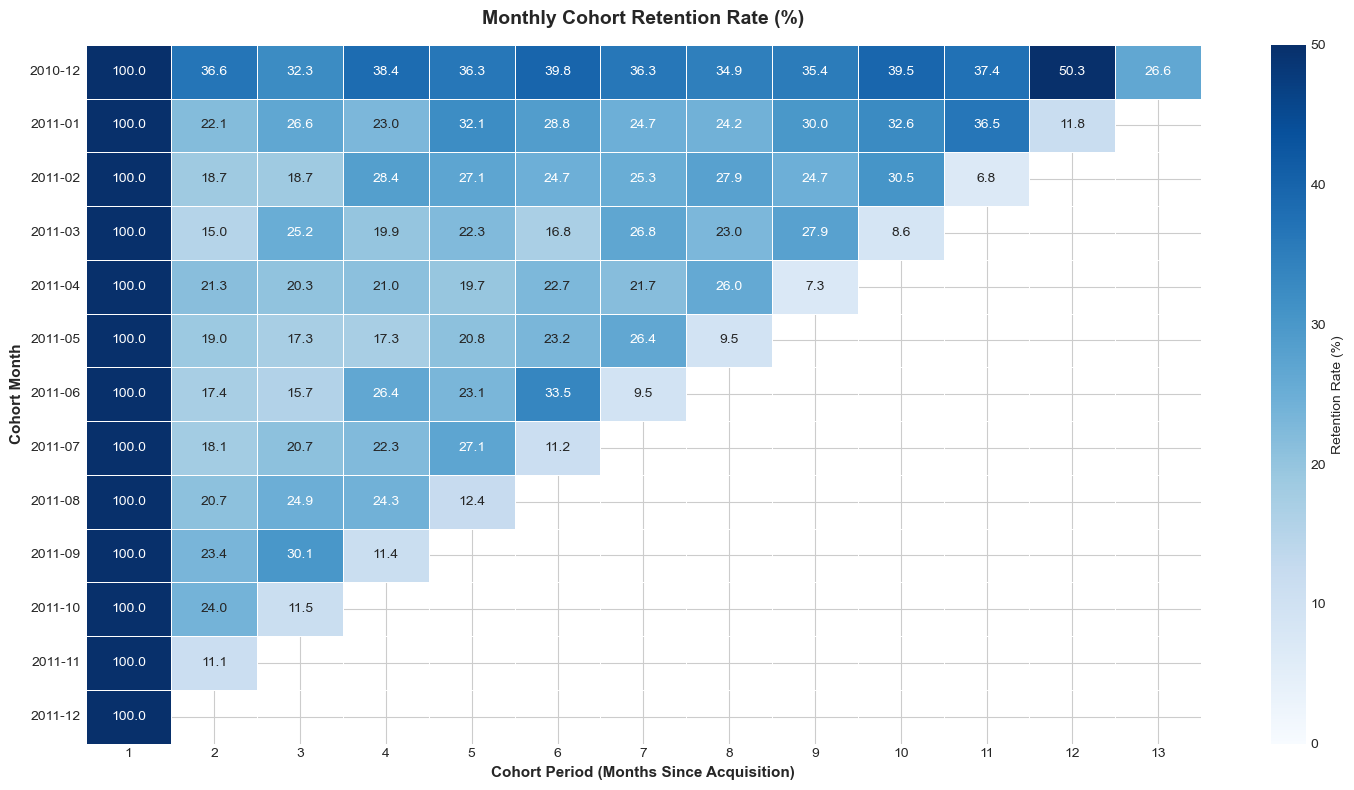

In [7]:
# Calculate Percentage Retention Rates
cohort_sizes = cohort_counts.iloc[:, 0]
retention_matrix = cohort_counts.divide(cohort_sizes, axis=0) * 100.0

# Plot Retention Heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    vmin=0.0,
    vmax=50.0,
    cbar_kws={'label': 'Retention Rate (%)'},
    linewidths=0.5
)
plt.title('Monthly Cohort Retention Rate (%)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Cohort Period (Months Since Acquisition)', fontsize=11, fontweight='bold')
plt.ylabel('Cohort Month', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

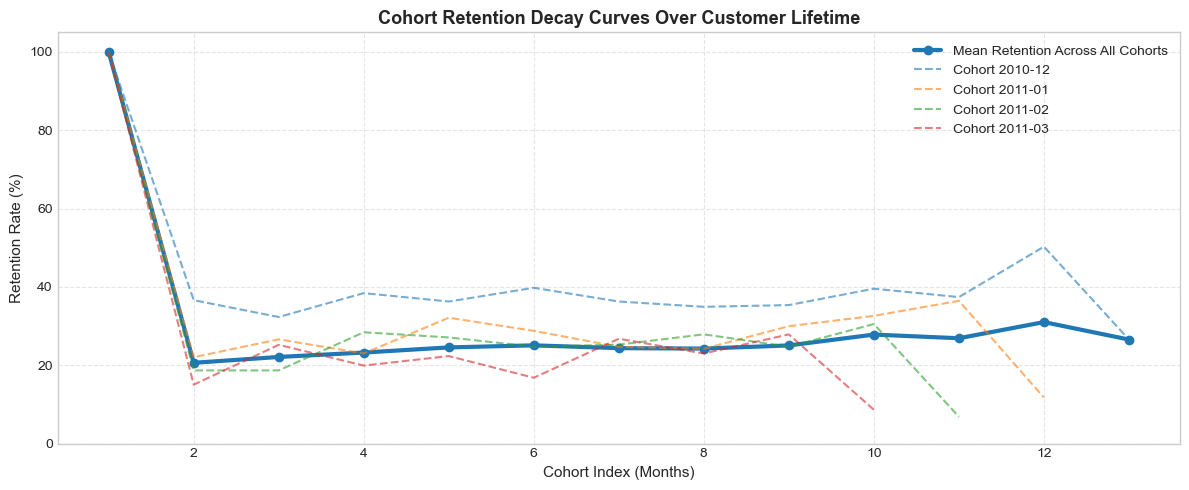

Key Metric: Average Month-1 Retention Rate is 20.62%


In [8]:
# Average Retention Decay Curve Across Cohorts
mean_retention = retention_matrix.mean(axis=0)

plt.figure(figsize=(12, 5))
plt.plot(mean_retention.index, mean_retention.values, marker='o', color='#1f77b4', linewidth=3, label='Mean Retention Across All Cohorts')
for c in retention_matrix.index[:4]:
    s = retention_matrix.loc[c].dropna()
    plt.plot(s.index, s.values, linestyle='--', alpha=0.6, label=f'Cohort {c}')

plt.title('Cohort Retention Decay Curves Over Customer Lifetime', fontsize=13, fontweight='bold')
plt.xlabel('Cohort Index (Months)', fontsize=11)
plt.ylabel('Retention Rate (%)', fontsize=11)
plt.ylim(0, 105)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

print(f'Key Metric: Average Month-1 Retention Rate is {mean_retention[2]:.2f}%')

## 5. RFM (Recency, Frequency, Monetary) Customer Segmentation

### Conceptual Definitions:
- **Recency ($R$):** Number of days elapsed since the customer's last recorded purchase relative to a benchmark date (set to 1 day after the maximum dataset timestamp).
- **Frequency ($F$):** Number of unique purchase transactions (invoices) completed by the customer.
- **Monetary ($M$):** Cumulative spending across all purchases made by the customer.

### Scoring Methodology:
Each metric is segmented into quintiles (scores from 1 to 5):
- **$R$-Score:** Inverted quintile (most recent purchases receive score 5; least recent receive score 1).
- **$F$-Score:** Rank-based quintile (highest order counts receive score 5).
- **$M$-Score:** Spending quintile (highest cumulative expenditure receives score 5).

In [9]:
# Compute RFM Metrics
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)
print(f'Snapshot evaluation date: {snapshot_date}')

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda d: (snapshot_date - d.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

rfm.describe().round(2)

Snapshot evaluation date: 2011-12-10 12:50:00


,CustomerID,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00,4338.00
mean,15300.41,92.54,4.27,2054.27
std,1721.81,100.01,7.70,8989.23
min,12346.00,1.00,1.00,3.75
25%,13813.25,18.00,1.00,307.41
50%,15299.50,51.00,2.00,674.48
75%,16778.75,142.00,5.00,1661.74
max,18287.00,374.00,209.00,280206.02


In [10]:
# Assign 1-5 Quantile Scores
r_labels = [5, 4, 3, 2, 1]
f_labels = [1, 2, 3, 4, 5]
m_labels = [1, 2, 3, 4, 5]

rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=r_labels).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=f_labels).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=m_labels).astype(int)

rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score
0,12346,326,1,77183.60,1,1,5,115,7
1,12347,2,7,4310.00,5,5,5,555,15
2,12348,75,4,1797.24,2,4,4,244,10
3,12349,19,1,1757.55,4,1,4,414,9
4,12350,310,1,334.40,1,1,2,112,4


In [11]:
# Rule-based Customer Segmentation Function
def assign_segment(row):
    r = row['R_Score']
    f = row['F_Score']
    if r in [4, 5] and f in [4, 5]:
        return 'Champions'
    elif r in [3, 4, 5] and f in [3, 4, 5]:
        return 'Loyal Customers'
    elif r in [4, 5] and f in [2, 3]:
        return 'Potential Loyalists'
    elif r in [4, 5] and f == 1:
        return 'New Customers'
    elif r in [3, 4] and f == 1:
        return 'Promising'
    elif r in [2, 3] and f in [2, 3]:
        return 'Customers Needing Attention'
    elif r in [2, 3] and f in [1, 2]:
        return 'About to Sleep'
    elif r in [1, 2] and f in [2, 3, 4, 5]:
        return 'At Risk'
    elif r == 1 and f in [4, 5]:
        return 'Can\'t Lose Them'
    else:
        return 'Hibernating / Lost'

rfm['Customer_Segment'] = rfm.apply(assign_segment, axis=1)

# Segment Aggregations
segment_summary = rfm.groupby('Customer_Segment').agg(
    Customer_Count=('CustomerID', 'count'),
    Recency_Mean=('Recency', 'mean'),
    Frequency_Mean=('Frequency', 'mean'),
    Monetary_Mean=('Monetary', 'mean'),
    Monetary_Total=('Monetary', 'sum')
).reset_index()

total_cust = len(rfm)
total_rev = rfm['Monetary'].sum()
segment_summary['Customer_Share_%'] = (segment_summary['Customer_Count'] / total_cust * 100).round(2)
segment_summary['Revenue_Share_%'] = (segment_summary['Monetary_Total'] / total_rev * 100).round(2)
segment_summary.sort_values(by='Monetary_Total', ascending=False)

,Customer_Segment,Customer_Count,Recency_Mean,Frequency_Mean,Monetary_Mean,Monetary_Total,Customer_Share_%,Revenue_Share_%
2,Champions,1139,13.311677,9.986831,5204.323012,5927723.911,26.26,66.52
5,Loyal Customers,821,38.043849,3.643118,1651.333386,1355744.710,18.93,15.21
1,At Risk,717,215.926081,2.789400,1008.494088,723090.261,16.53,8.11
3,Customers Needing Attention,615,98.403252,1.695935,648.454475,398799.502,14.18,4.48
4,Hibernating / Lost,364,278.684066,1.000000,544.054038,198035.670,8.39,2.22
7,Potential Loyalists,178,18.528090,1.432584,531.920506,94681.850,4.10,1.06
0,About to Sleep,199,118.090452,1.000000,466.937789,92920.620,4.59,1.04
8,Promising,164,53.914634,1.000000,420.284512,68926.660,3.78,0.77
6,New Customers,141,18.503546,1.000000,365.139858,51484.720,3.25,0.58


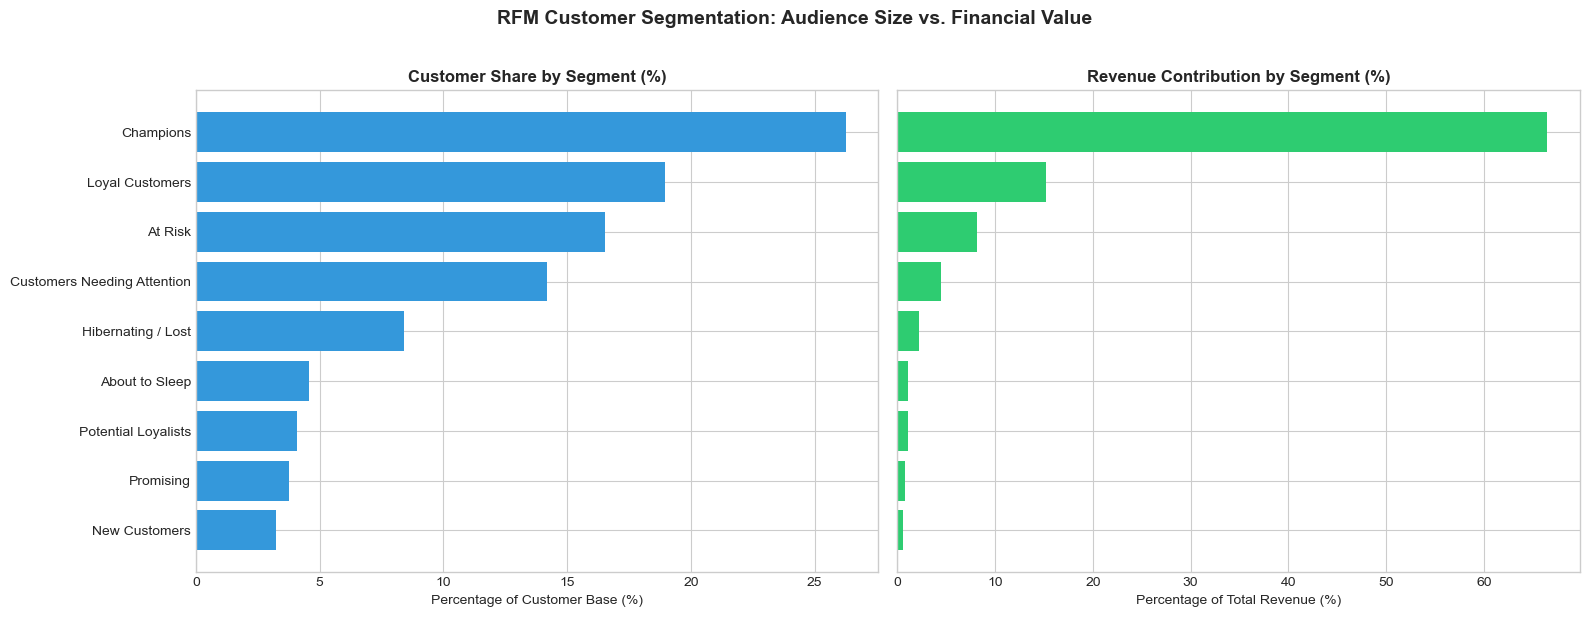

In [12]:
# Visualize RFM Segment Breakdown
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

df_cust = segment_summary.sort_values(by='Customer_Share_%', ascending=True)
axes[0].barh(df_cust['Customer_Segment'], df_cust['Customer_Share_%'], color='#3498db')
axes[0].set_title('Customer Share by Segment (%)', fontweight='bold')
axes[0].set_xlabel('Percentage of Customer Base (%)')

axes[1].barh(df_cust['Customer_Segment'], df_cust['Revenue_Share_%'], color='#2ecc71')
axes[1].set_title('Revenue Contribution by Segment (%)', fontweight='bold')
axes[1].set_xlabel('Percentage of Total Revenue (%)')

plt.suptitle('RFM Customer Segmentation: Audience Size vs. Financial Value', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Machine Learning Segmentation: K-Means Clustering

While rule-based RFM quantiles offer intuitive heuristic segments, **K-Means Clustering** provides unsupervised algorithmic grouping based on natural feature geometry.

### Machine Learning Preprocessing Steps:
1. **Handle Skewness:** RFM distributions exhibit extreme right-skew (Pareto distribution). We apply a natural logarithm transformation: $\log(x + 1)$.
2. **Feature Standardization:** K-Means calculates Euclidean distance; we normalize features using `StandardScaler` to achieve zero mean and unit variance ($\mu=0, \sigma=1$).
3. **Elbow Method & Silhouette Analysis:** Determine optimal cluster count $k$ by evaluating within-cluster inertia and silhouette coefficients.

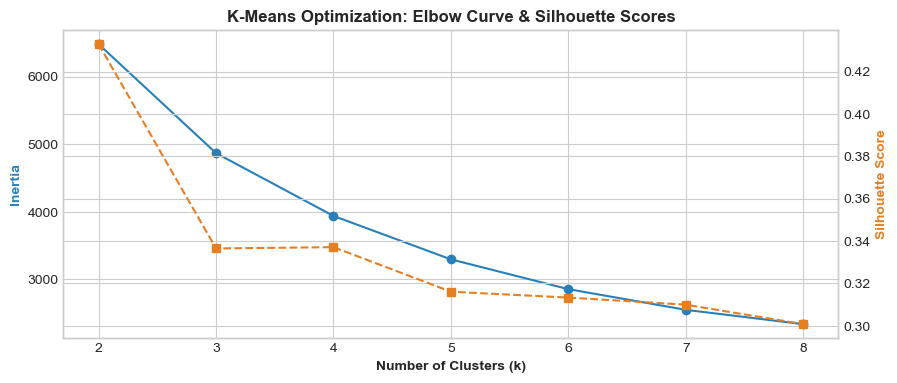

In [13]:
# Preprocess RFM Features for Clustering
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']].copy()
rfm_log = np.log1p(rfm_features)

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# Evaluate Elbow and Silhouette Scores
k_range = range(2, 9)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, labels))

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(list(k_range), inertias, marker='o', color='#2980b9')
ax1.set_xlabel('Number of Clusters (k)', fontweight='bold')
ax1.set_ylabel('Inertia', color='#2980b9', fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(list(k_range), silhouettes, marker='s', linestyle='--', color='#e67e22')
ax2.set_ylabel('Silhouette Score', color='#e67e22', fontweight='bold')
plt.title('K-Means Optimization: Elbow Curve & Silhouette Scores', fontweight='bold')
plt.show()

In [14]:
# Fit Final K-Means Model (k=4)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, max_iter=300, random_state=42)
rfm['KMeans_Cluster'] = kmeans.fit_predict(rfm_scaled)

# Compute Cluster Profiling
cluster_profiles = rfm.groupby('KMeans_Cluster').agg(
    Count=('CustomerID', 'count'),
    Recency_Mean=('Recency', 'mean'),
    Frequency_Mean=('Frequency', 'mean'),
    Monetary_Mean=('Monetary', 'mean'),
    Monetary_Total=('Monetary', 'sum')
).reset_index()

cluster_profiles['Customer_Share_%'] = (cluster_profiles['Count'] / len(rfm) * 100).round(2)
cluster_profiles['Revenue_Share_%'] = (cluster_profiles['Monetary_Total'] / rfm['Monetary'].sum() * 100).round(2)
cluster_profiles.sort_values(by='Monetary_Total', ascending=False)

,KMeans_Cluster,Count,Recency_Mean,Frequency_Mean,Monetary_Mean,Monetary_Total,Customer_Share_%,Revenue_Share_%
1,1,716,12.131285,13.713687,8074.266872,5781175.080,16.51,64.87
2,2,1173,71.084399,4.083546,1802.829005,2114718.423,27.04,23.73
3,3,1612,182.496898,1.318238,343.450032,553641.451,37.16,6.21
0,0,837,18.124253,2.148148,551.819534,461872.950,19.29,5.18


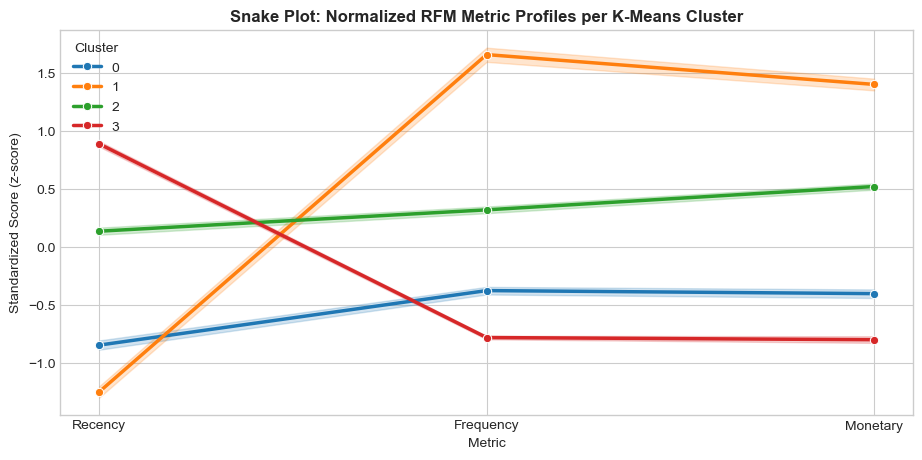

In [15]:
# Snake Plot (Cluster Centroid Comparison)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])
rfm_scaled_df['Cluster'] = rfm['KMeans_Cluster']

melted_rfm = pd.melt(
    rfm_scaled_df.reset_index(),
    id_vars=['Cluster'],
    value_vars=['Recency', 'Frequency', 'Monetary'],
    var_name='Metric',
    value_name='Normalized_Score'
)

plt.figure(figsize=(11, 5))
sns.lineplot(data=melted_rfm, x='Metric', y='Normalized_Score', hue='Cluster', palette='tab10', marker='o', linewidth=2.5)
plt.title('Snake Plot: Normalized RFM Metric Profiles per K-Means Cluster', fontweight='bold')
plt.ylabel('Standardized Score (z-score)')
plt.show()

## 7. Actionable Business Insights & Strategic Recommendations

### 1. The High-Value Pareto Reality:
- **Champions Segment:** Represents **26.3%** of customers but generates **66.5%** of all enterprise revenue with an average spend of **£5,204.32**.
- *Action:* Implement white-glove VIP loyalty accounts, tier-exclusive preview access, dedicated account managers, and surprise gifting to maximize retention.

### 2. At Risk Churn Prevention:
- **At Risk Segment:** Represents **16.5%** of customers and **8.1%** of revenue (£723k total spend). These were previously active buyers who have not purchased in over 150 days.
- *Action:* Trigger time-sensitive win-back email drip sequences offering personalized bundles, replenishment discounts, and feedback surveys.

### 3. Mitigating the Month-1 Cohort Drop-Off:
- Cohort analysis demonstrates that customer retention drops from 100% in Month 0 to ~20.6% in Month 1 across all cohorts.
- *Action:* Introduce an automated onboarding engagement cycle within 14 days of first purchase (e.g., cross-sell guides, second-purchase discount incentives, and gamified loyalty reward points).

In [16]:
# Summary of customer segmentation
print(f'Total segmented customers: {len(rfm):,}')
rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'RFM_Score', 'Customer_Segment', 'KMeans_Cluster']].head(10)


Total segmented customers: 4,338


,CustomerID,Recency,Frequency,Monetary,RFM_Score,Customer_Segment,KMeans_Cluster
0,12346,326,1,77183.60,7,Hibernating / Lost,2
1,12347,2,7,4310.00,15,Champions,1
2,12348,75,4,1797.24,10,At Risk,2
3,12349,19,1,1757.55,9,New Customers,0
4,12350,310,1,334.40,4,Hibernating / Lost,3
5,12352,36,8,2506.04,13,Loyal Customers,2
6,12353,204,1,89.00,3,Hibernating / Lost,3
7,12354,232,1,1079.40,6,Hibernating / Lost,3
8,12355,214,1,459.40,4,Hibernating / Lost,3
9,12356,23,3,2811.43,12,Loyal Customers,2
